# 2002 AA29 and Apophis

## Initialize

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from astropy.time import Time
from astroquery.jplhorizons import Horizons

In [3]:
AU_TO_KM = 149597870.7
EARTH_RADIUS_KM = 6371.0
DAYS_PER_JULIAN_YEAR = 365.25

OBJECT = {
    'SUN': {
        'id': '10',
        'name': 'Sun',
        'color': 'darkorange'
    },
    'EARTH': {
        'id': '3',
        'name': 'Earth',
        'color': 'dodgerblue'
    },
    'APOPHIS': {
        'id': '99942',
        'name': '99942 Apophis',
        'color': 'indianred'
    },
    '2002AA29': {
        'id': '2002 AA29',
        'name': '2002 AA29',
        'color': 'lightseagreen'
    }
}

# 2002 AA29 Long Term: 2461041.5 (2026) to 2725476.5 (2750)
EPOCH_START_2002AA29_JD = 2461041.5
EPOCH_END_2002AA29_JD = 2725476.5
DURATION_2002AA29_DAYS = EPOCH_END_2002AA29_JD - EPOCH_START_2002AA29_JD

# Apophis Encounter: 2462239.5 to 2462241.5
EPOCH_START_APOPHIS_JD = 2462239.5

In [166]:
# Load data
col = ['time', 'long', 'x', 'y', 'z', 'vx', 'vy', 'vz']

# 2002 AA29 Long Term: 2634166.5 to 2650691.5
r_aa = pd.read_csv('2002AA29/2002AA29.aei', sep='\s+', skiprows=4, names=col)
r_e = pd.read_csv('2002AA29/EARTH.aei', sep='\s+', skiprows=4, names=col)

# Apophis Encounter: 2462239.5 to 2462241.5
r_ap_enc = pd.read_csv('Apophis/APOPHIS.aei', sep='\s+', skiprows=4, names=col)
r_e_enc = pd.read_csv('Apophis/EARTH.aei', sep='\s+', skiprows=4, names=col)

In [5]:
# Horizons Data
duration_years = 100
stop_jd = EPOCH_START_2002AA29_JD + (duration_years * DAYS_PER_JULIAN_YEAR)

start_iso = Time(EPOCH_START_2002AA29_JD, format='jd').to_value('iso', subfmt='date')
stop_iso = Time(stop_jd, format='jd').to_value('iso', subfmt='date')

epochs = {
    'start': start_iso,
    'stop': stop_iso,
    'step': '200d'
}

obj_aa_hor = Horizons(id=OBJECT['2002AA29']['id'], location='@sun', epochs=epochs)
vec_aa_hor = obj_aa_hor.vectors()

#obj_ap_hor = Horizons(id=OBJECT['APOPHIS']['id'], location='@sun', epochs=epochs)
#vec_ap_hor = obj_ap_hor.vectors()

obj_e_hor = Horizons(id=OBJECT['EARTH']['id'], location='@sun', epochs=epochs)
vec_e_hor = obj_e_hor.vectors()

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [6]:
def get_rotation_coords(df_target, df_earth):
    theta = np.arctan2(df_earth['y'], df_earth['x'])
    
    x_rot = df_target['x'] * np.cos(theta) + df_target['y'] * np.sin(theta) - (df_earth['x'] * np.cos(theta) + df_earth['y'] * np.sin(theta))
    y_rot = -df_target['x'] * np.sin(theta) + df_target['y'] * np.cos(theta) - (-df_earth['x'] * np.sin(theta) + df_earth['y'] * np.cos(theta))
    z_rot = df_target['z'] - df_earth['z']
    
    return x_rot, y_rot, z_rot

def get_jacobi_constant(df_target, df_earth):
    mu = 3.003489e-6 
    k = 0.01720209895

    x, y, z = df_target['x'].values, df_target['y'].values, df_target['z'].values
    vx, vy, vz = df_target['vx'].values, df_target['vy'].values, df_target['vz'].values
    ex, ey, ez = df_earth['x'].values, df_earth['y'].values, df_earth['z'].values
    
    r1 = np.sqrt(x**2 + y**2 + z**2)
    r2 = np.sqrt((x-ex)**2 + (y-ey)**2 + (z-ez)**2)
    
    potential = (1 - mu) / r1 + mu / r2
    angular_momentum = (x * vy - y * vx) / k
    v_squared = (vx**2 + vy**2 + vz**2) / k**2
    
    cj = 2 * potential + 2 * angular_momentum - v_squared
    
    return cj

def get_iso_date(t_days):
    jd = t_days + EPOCH_START_2002AA29_JD
    return Time(jd, format='jd').iso[:10]

## ICRF

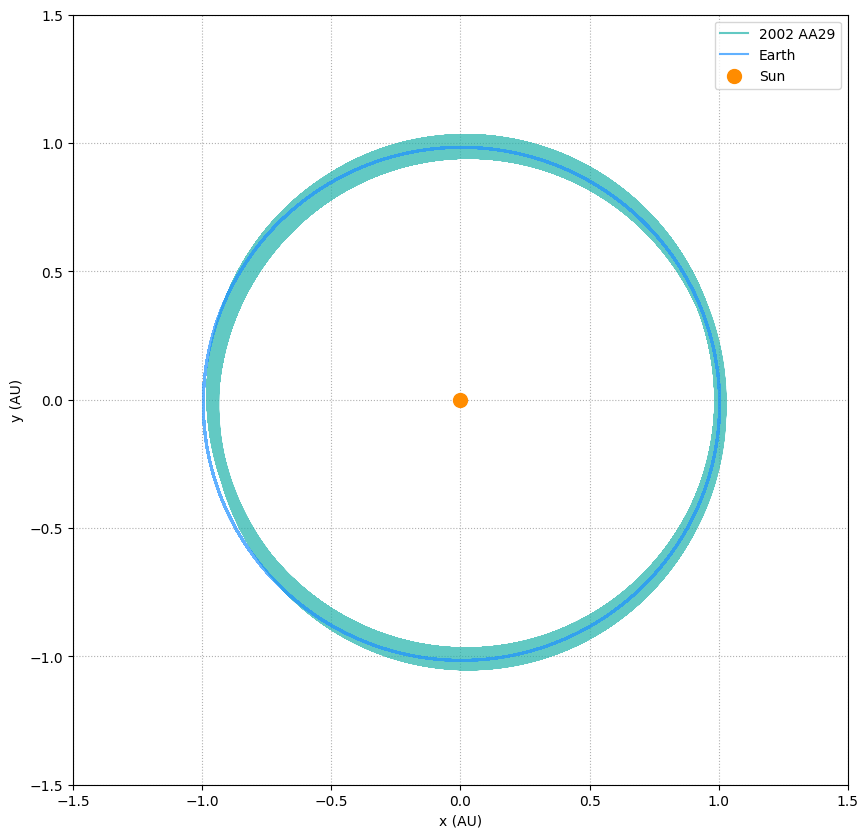

In [141]:
# ICRF Plotting
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(r_aa['x'], r_aa['y'], label=OBJECT['2002AA29']['name'], color=OBJECT['2002AA29']['color'], alpha=0.7, zorder=2)
ax.plot(r_e['x'], r_e['y'], label=OBJECT['EARTH']['name'], color=OBJECT['EARTH']['color'], alpha=0.7, zorder=3)
ax.scatter(0, 0, label=OBJECT['SUN']['name'], color=OBJECT['SUN']['color'], s=100, zorder=2)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.legend()
ax.grid(True, linestyle=':')

plt.show()

## Earth-centric Rotational Coordinates

### Jacobi Constant

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 52669 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


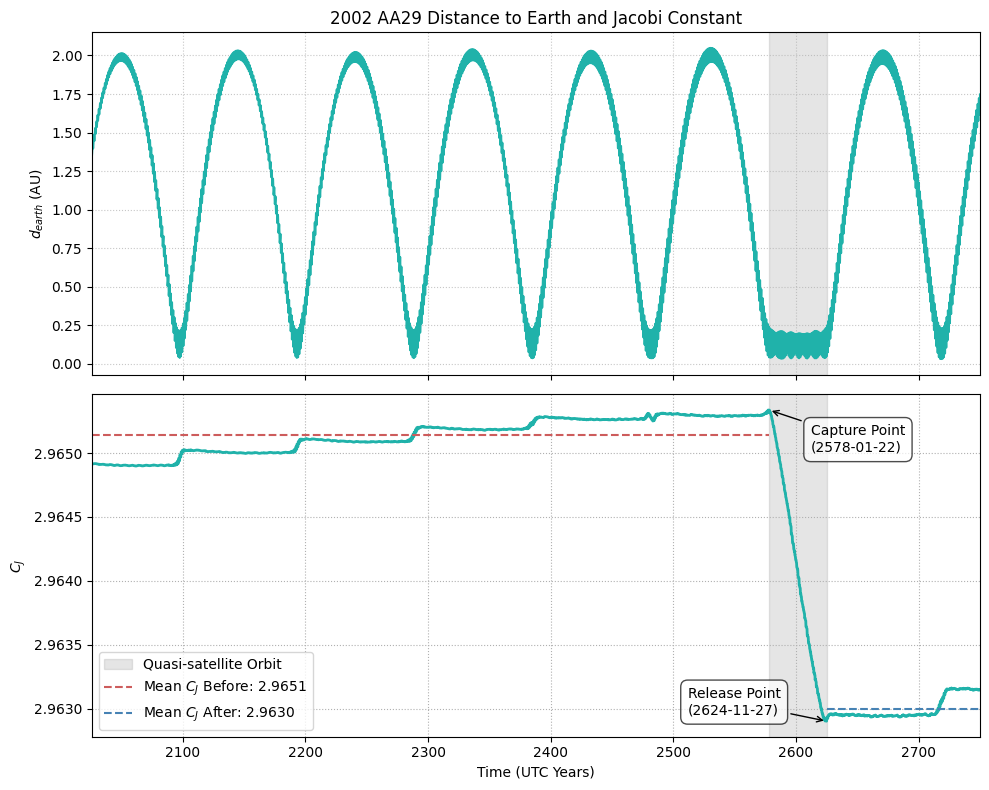

In [153]:
# Data Process

x_rot_aa, y_rot_aa, z_rot_aa = get_rotation_coords(r_aa, r_e)
dist = np.sqrt(x_rot_aa**2 + y_rot_aa**2 + z_rot_aa**2)

cj_values = get_jacobi_constant(r_aa, r_e)

# Capture and Release Point
idx_capture = np.argmax(cj_values)
idx_release = np.argmin(cj_values)

t_capture = r_aa['time'][idx_capture]
t_release = r_aa['time'][idx_release]
capture_duration = t_release - t_capture

mask_pre_capture  = r_aa['time'] < t_capture
mask_post_release = r_aa['time'] > t_release

cj_mean_pre  = np.mean(cj_values[mask_pre_capture])
cj_mean_post = np.mean(cj_values[mask_post_release])

# Time processing
time_jd = r_aa['time'].values + EPOCH_START_2002AA29_JD
time_dt = Time(time_jd, format='jd').to_datetime()

dt_capture = time_dt[idx_capture]
dt_release = time_dt[idx_release]
dt_start = time_dt[0]
dt_end = time_dt[-1]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Distance
ax1.set_title(f"2002 AA29 Distance to Earth and Jacobi Constant")

ax1.plot(time_dt, dist, color=OBJECT['2002AA29']['color'])
ax1.axvspan(dt_capture, dt_release, color='gray', alpha=0.2, zorder=0)

ax1.set_ylabel('$d_{earth}$ (AU)')
ax1.grid(True, linestyle=':', alpha=0.7)

# Jacobi const.
ax2.plot(time_dt, cj_values, color=OBJECT['2002AA29']['color'], lw=2)
ax2.axvspan(dt_capture, dt_release, label='Quasi-satellite Orbit', color='gray', alpha=0.2, zorder=0)

ax2.hlines(cj_mean_pre, dt_start, dt_capture, colors='indianred', linestyles='--', label=f'Mean $C_J$ Before: {cj_mean_pre:.4f}')
ax2.hlines(cj_mean_post, dt_release, dt_end, colors='steelblue', linestyles='--', label=f'Mean $C_J$ After: {cj_mean_post:.4f}')

ax2.annotate(f'Capture Point\n({get_iso_date(t_capture)})',
             xy=(dt_capture, np.max(cj_values)), 
             xytext=(30, -30),
             textcoords='offset points', 
             arrowprops=dict(arrowstyle='->', color='black'),
             bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.5'), 
             zorder=4)

ax2.annotate(f'Release Point\n({get_iso_date(t_release)})',
             xy=(dt_release, np.min(cj_values)), 
             xytext=(-100, 5),
             textcoords='offset points', 
             arrowprops=dict(arrowstyle='->', color='black'),
             bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.5'), 
             zorder=4)

ax2.set_xlim(dt_start, dt_end)
ax2.set_xlabel('Time (UTC Years)')
ax2.set_ylabel('$C_J$')
ax2.legend(loc='lower left')
ax2.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

### Orbit Plot

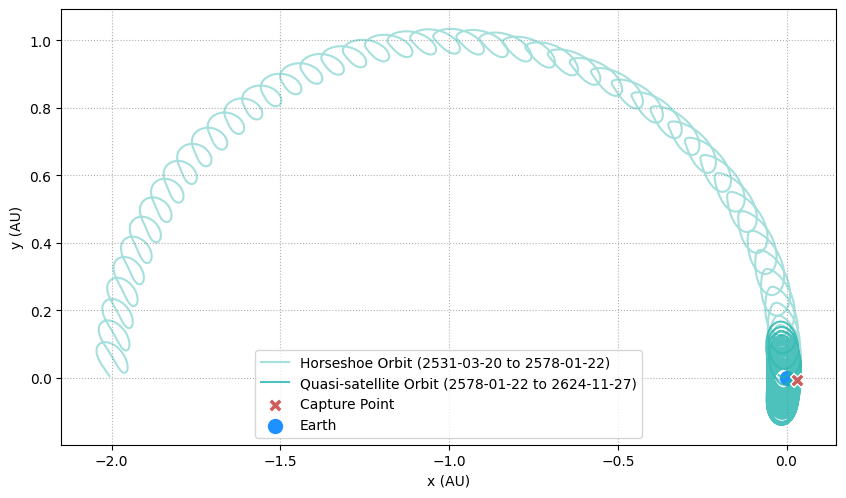

In [139]:
# Orbital Phase Analysis
t_hs_start = t_capture - capture_duration
mask_hs = (r_aa['time'] >= t_hs_start) & (r_aa['time'] <= t_capture)
mask_qs = (r_aa['time'] >= t_capture) & (r_aa['time'] <= t_release)

start_hs_iso = get_iso_date(t_hs_start)
start_qs_iso = get_iso_date(t_capture)
end_qs_iso = get_iso_date(t_release)

x_cap = x_rot_aa[idx_capture]
y_cap = y_rot_aa[idx_capture]
z_cap = z_rot_aa[idx_capture]

# Rotational Coordinates Plotting
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(x_rot_aa[mask_hs], y_rot_aa[mask_hs], label=f'Horseshoe Orbit ({start_hs_iso} to {start_qs_iso})', color=OBJECT['2002AA29']['color'], alpha=0.4, zorder=2)
ax.plot(x_rot_aa[mask_qs], y_rot_aa[mask_qs], label=f'Quasi-satellite Orbit ({start_qs_iso} to {end_qs_iso})', color=OBJECT['2002AA29']['color'], alpha=0.8, zorder=3)

ax.scatter(x_cap, y_cap, label='Capture Point', color='indianred', marker='X', s=100, zorder=4, edgecolors='white')

ax.scatter(0, 0, label=OBJECT['EARTH']['name'], color=OBJECT['EARTH']['color'], s=100, zorder=2)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')

ax.legend()
ax.set_aspect('equal')
ax.grid(True, linestyle=':')

plt.show()

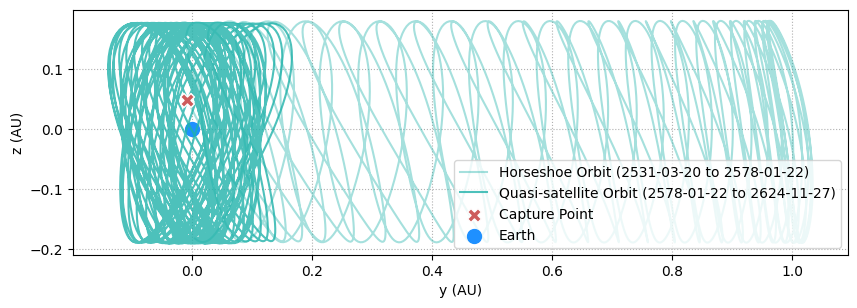

In [138]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(y_rot_aa[mask_hs], z_rot_aa[mask_hs], label=f'Horseshoe Orbit ({start_hs_iso} to {start_qs_iso})', color=OBJECT['2002AA29']['color'], alpha=0.4, zorder=2)
ax.plot(y_rot_aa[mask_qs], z_rot_aa[mask_qs], label=f'Quasi-satellite Orbit ({start_qs_iso} to {end_qs_iso})', color=OBJECT['2002AA29']['color'], alpha=0.8, zorder=3)

ax.scatter(y_cap, z_cap, label='Capture Point', color='indianred', marker='X', s=100, zorder=4, edgecolors='white')

ax.scatter(0, 0, label=OBJECT['EARTH']['name'], color=OBJECT['EARTH']['color'], s=100, zorder=2)

ax.set_xlabel('y (AU)')
ax.set_ylabel('z (AU)')
ax.set_aspect('equal')
ax.legend(loc='lower right')
ax.grid(True, linestyle=':')

plt.show()

## Apophis Encounter

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


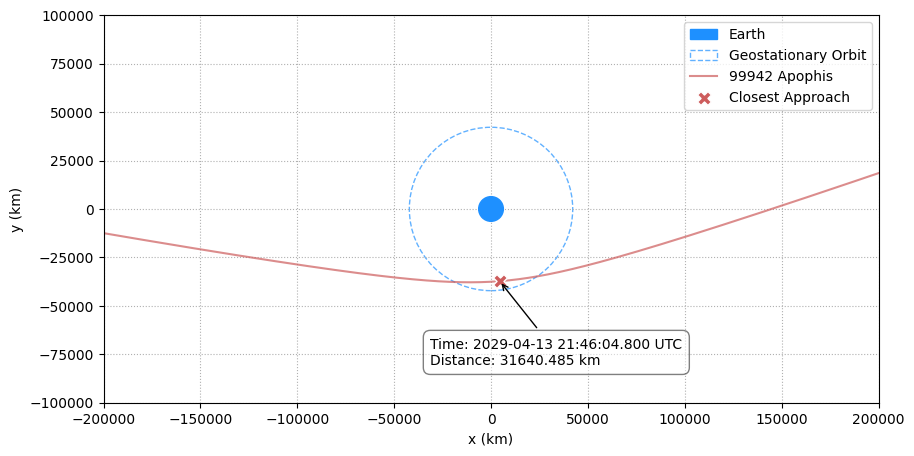

In [202]:
# Rotational Coordinates
x_rot_au, y_rot_au, z_rot_au = get_rotation_coords(r_ap_enc, r_e_enc)

x_rot_enc = x_rot_au * AU_TO_KM
y_rot_enc = y_rot_au * AU_TO_KM
z_rot_enc = z_rot_au * AU_TO_KM

# Closest Approach
enc_dist = np.sqrt(x_rot_enc**2 + y_rot_enc**2 + z_rot_enc**2)
min_idx = enc_dist.idxmin()
closest_x, closest_y, closest_z = x_rot_enc[min_idx], y_rot_enc[min_idx], z_rot_enc[min_idx]

min_dist = enc_dist[min_idx] - EARTH_RADIUS_KM
min_time = r_ap_enc['time'][min_idx] + EPOCH_START_APOPHIS_JD
min_time_iso = Time(min_time, format='jd').iso

# Rotational Coordinates Plotting
fig, ax = plt.subplots(figsize=(10, 10))

earth = plt.Circle((0, 0), EARTH_RADIUS_KM, label=OBJECT['EARTH']['name'], color=OBJECT['EARTH']['color'], zorder=2)
ax.add_patch(earth)

geo = plt.Circle((0, 0), 42164, label='Geostationary Orbit', color=OBJECT['EARTH']['color'], fill=False, linestyle='--', alpha=0.7, zorder=1)
ax.add_patch(geo)

ax.plot(x_rot_enc, y_rot_enc, label=OBJECT['APOPHIS']['name'], color=OBJECT['APOPHIS']['color'], alpha=0.7, zorder=2)
ax.scatter(closest_x, closest_y, label='Closest Approach', color=OBJECT['APOPHIS']['color'], marker='X', edgecolors='white', s=100, zorder=3)

label_text = f"Time: {min_time_iso} UTC\nDistance: {min_dist:.3f} km"
ax.annotate(label_text,
            xy=(closest_x, closest_y), 
            xytext=(-50, -60),
            textcoords='offset points', 
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.5'),
            zorder=4)

ax.set_xlim(-200000, 200000)
ax.set_ylim(-100000, 100000)
ax.set_aspect('equal')
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.legend()
ax.grid(True, linestyle=':')

plt.show()

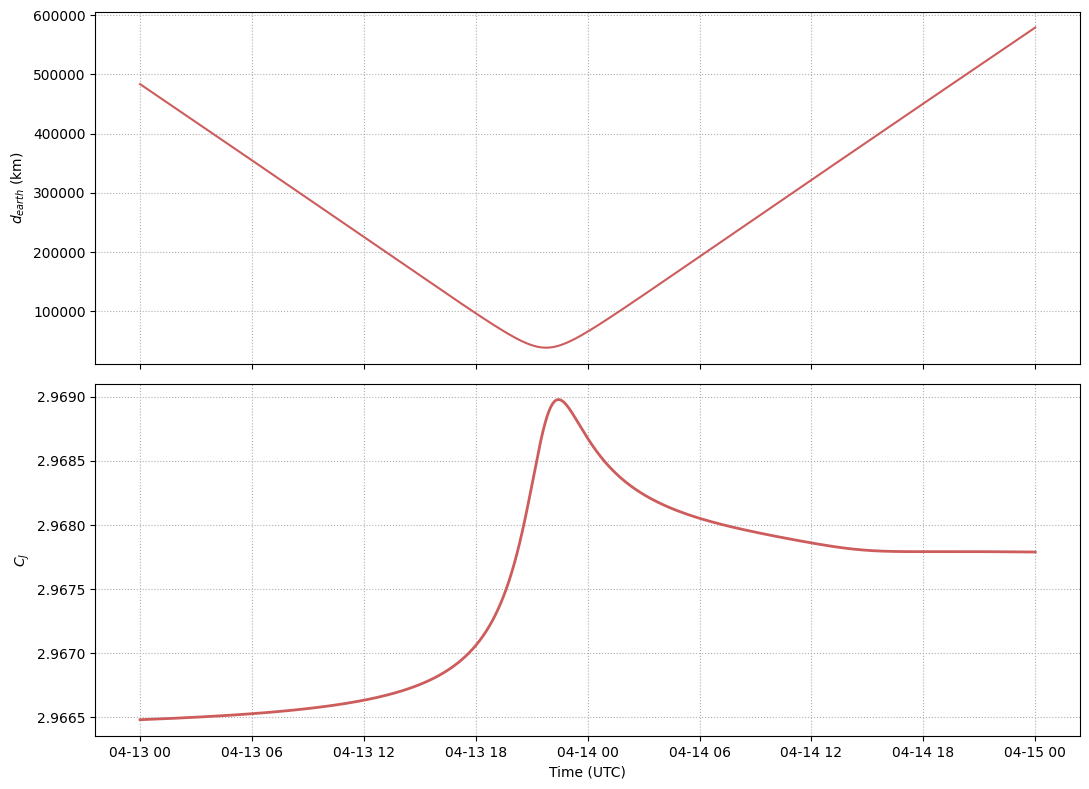

In [207]:
cj_values = get_jacobi_constant(r_ap_enc, r_e_enc)

time_jd = r_ap_enc['time'] + EPOCH_START_APOPHIS_JD
time_dt = Time(time_jd, format='jd').to_datetime()

dt_dist = time_dt[min_idx]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Distance
ax1.plot(time_dt, enc_dist, color=OBJECT['APOPHIS']['color'], lw=1.5)
ax1.set_ylabel('$d_{earth}$ (km)')
ax1.grid(True, linestyle=':')

# Jacobi constant
ax2.plot(time_dt, cj_values, color=OBJECT['APOPHIS']['color'], lw=2)

ax2.set_xlabel('Time (UTC)')
ax2.set_ylabel('$C_J$')

ax2.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

## Horizons Data Comparison

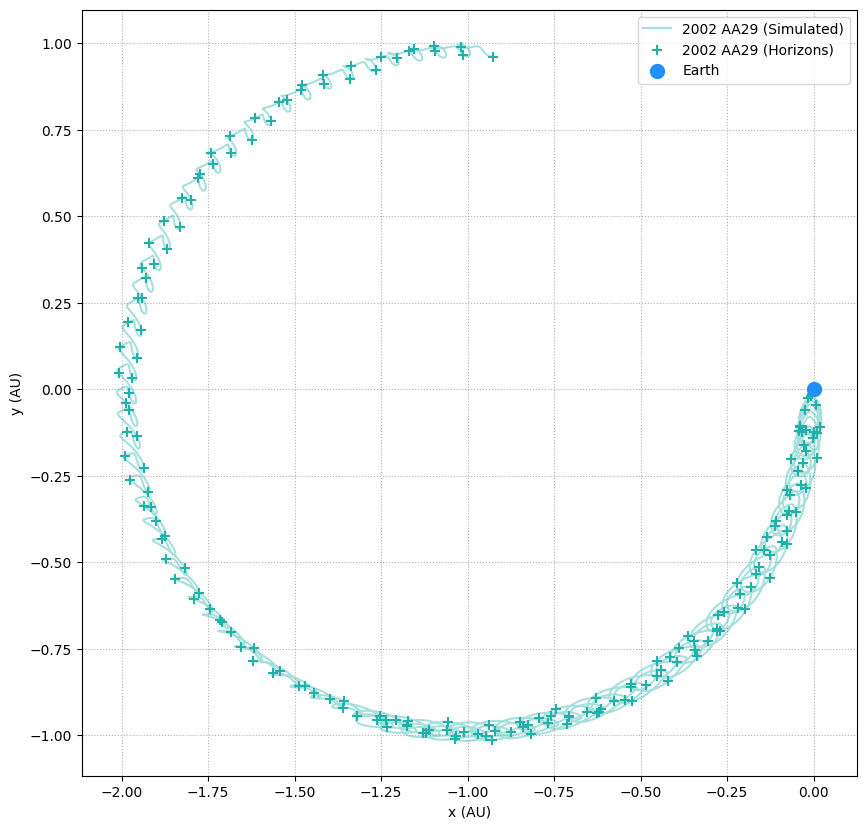

In [136]:
# Rotation Coordinates
x_rot_aa_hor, y_rot_aa_hor, z_rot_aa_hor = get_rotation_coords(vec_aa_hor, vec_e_hor)

mask_hor = (r_aa['time'] >= 0) & (r_aa['time'] <= 100 * DAYS_PER_JULIAN_YEAR)

# Horizons Rotational Coordinates Plotting
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(x_rot_aa[mask_hor], y_rot_aa[mask_hor], label=f"{OBJECT['2002AA29']['name']} (Simulated)", color=OBJECT['2002AA29']['color'], alpha=0.4, zorder=2)
ax.scatter(x_rot_aa_hor, y_rot_aa_hor, label=f"{OBJECT['2002AA29']['name']} (Horizons)", color=OBJECT['2002AA29']['color'], marker='+', s=50, zorder=3)

ax.scatter(0, 0, label=OBJECT['EARTH']['name'], color=OBJECT['EARTH']['color'], s=100, zorder=3)

ax.set_aspect('equal')
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.legend()
ax.grid(True, linestyle=':')

plt.show()